# Avaliação Prática 1

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

SEMENTE = 42
pd.set_option("display.width", 100)

## Exercício 1 (4,0 pontos)
Uma cooperativa agrícola quer estimar a produtividade de um talhão de soja antes do plantio, para planejar a compra de insumos e a contratação de armazenagem. Ela reuniu o histórico de 400 talhões de safras já encerradas no arquivo talhoes_soja.csv

In [28]:
df_soja = pd.read_csv("talhoes_soja.csv")
display(df_soja.head())

,id_talhao,area_ha,chuva_mm,ph_solo,adubo_kg_ha,receita_bruta_rs_ha,produtividade_sacas_ha
0,1,151,783,6.8,214,7308,56.1
1,2,516,830,6.6,227,8226,63.1
2,3,379,1014,6.9,390,9390,72.5
3,4,303,544,5.7,293,7384,57.0
4,5,290,571,5.1,151,5960,45.8


### a) Identifique o tipo de problema (supervisionado ou não, e a natureza da variável a prever) e escolha o algoritmo que utilizará, justificando a escolha. [0,5]

R: Trata-se de um problema supervisionado, pois temos o histórico com os rótulos/respostas (produtividade) já conhecidos para treinar o modelo. A natureza da variável a prever (`produtividade_sacas_ha`) é numérica, logo, se trata de um problema de regressão. Algoritmo escolhido: `LinearRegression` (Regressão Linear Múltipla), pois se trata de um algoritmo eficiente e capaz de estimar um valor numérico baseando-se em múltiplas variáveis de entrada.

### b) Defina quais colunas serão usadas como entradas do modelo e qual será a saída. Justifique a utilização ou a exclusão de cada coluna da tabela acima, tendo em mente o momento em que a previsão será feita. [0,5]

R: Entradas: `area_ha`, `chuva_mm`, `ph_solo`, `adubo_kg_ha`. Saída: `produtividade_sacas_ha`. Exclusões: `id_talhao` é apenas um identificador único, não possui influência sobre a colheita; `receita_bruta_rs_ha`: esta receita só será conhecida após a colheita, juntamente com a produtividade. Justificativas das inclusões:`area_ha`, `chuva_mm`, `ph_solo`, `adubo_kg_ha`: são todas as informações disponíveis ou projetadas antes ou durante o plantio e que têm impacto direto na produtividade.

In [29]:
X_soja = df_soja[["area_ha", "chuva_mm", "ph_solo", "adubo_kg_ha"]]
y_soja = df_soja["produtividade_sacas_ha"]

### c) Padronize as colunas chuva_mm e adubo_kg_ha com StandardScaler antes do treinamento (as demais colunas de entrada não devem ser padronizadas). Explique em que momento o StandardScaler deve ser ajustado (fit) em relação à divisão dos dados da validação e por quê. [1,0]

R: O `StandardScaler` deve ser ajustado apenas na massa de treino, e isso deve ser feito após a divisão da base de dados entre treino e validação. Isso ocorre para evitar o vazamento de dados. O uso de um `Pipeline` no Scikit-Learn resolve essa questão automaticamente durante a validação cruzada.

### d) Avalie o modelo com validação cruzada de 5 partições (embaralhadas, random_state=42). Escolha e justifique as métricas de desempenho adequadas ao tipo de problema; apresente o valor de cada métrica em cada partição, a média e o desvio-padrão, e interprete o resultado. [1,0]

R: Serão utilizadas duas métricas para a avaliação: MAE (Mean Absolute Error) e R² (Coeficiente de Determinação). Justificativa MAE: O MAE fornece a média do erro absoluto na mesma unidade da variável alvo (sacas por hectare). Diferente do MSE, ele é mais intuitivo de interpretar no contexto de negócio agrícola. Justificativa R²: Indica a proporção da variação na produtividade que o nosso modelo consegue explicar, medindo o quão bem a regressão se ajusta à realidade (o mais próximo de 1, melhor).


In [30]:
preprocessor_soja = ColumnTransformer(
    transformers=[
        ('padroniza', StandardScaler(), ['chuva_mm', 'adubo_kg_ha'])
    ],
    remainder='passthrough'
)

pipeline_soja = Pipeline([
    ('preprocessor', preprocessor_soja),
    ('modelo', LinearRegression())
])

kfold_soja = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)

resultados_cv = cross_validate(
    pipeline_soja, X_soja, y_soja, 
    cv=kfold_soja, 
    scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'}
)

mae_scores = -resultados_cv['test_mae']
r2_scores = resultados_cv['test_r2']

for i in range(5):
    print(f"Partição {i+1} | MAE: {mae_scores[i]:.2f} sacas/ha | R²: {r2_scores[i]:.4f}")

print("-" * 50)
print(f"Média MAE: {mae_scores.mean():.2f} sacas/ha | Desvio Padrão MAE: {mae_scores.std():.2f}")
print(f"Média R²:  {r2_scores.mean():.4f} | Desvio Padrão R²:  {r2_scores.std():.4f}")

print("\nInterpretação:")
print(f"O modelo erra em média {mae_scores.mean():.2f} sacas de soja por hectare em suas previsões.")
print(f"Ele consegue explicar aproximadamente {r2_scores.mean()*100:.1f}% da variância presente nos dados com as features utilizadas.")

Partição 1 | MAE: 2.56 sacas/ha | R²: 0.8873
Partição 2 | MAE: 2.56 sacas/ha | R²: 0.8933
Partição 3 | MAE: 2.62 sacas/ha | R²: 0.8892
Partição 4 | MAE: 2.19 sacas/ha | R²: 0.9422
Partição 5 | MAE: 2.40 sacas/ha | R²: 0.9057
--------------------------------------------------
Média MAE: 2.46 sacas/ha | Desvio Padrão MAE: 0.16
Média R²:  0.9035 | Desvio Padrão R²:  0.0204

Interpretação:
O modelo erra em média 2.46 sacas de soja por hectare em suas previsões.
Ele consegue explicar aproximadamente 90.4% da variância presente nos dados com as features utilizadas.


### e) Treine o modelo final com todos os dados e estime a produtividade (sacas por hectare) dos três talhões que serão plantados na próxima safra, descritos abaixo. [1,0]

In [31]:
pipeline_soja.fit(X_soja, y_soja)

novos_talhoes = pd.DataFrame({
    'area_ha': [100, 300, 500],
    'chuva_mm': [1000, 1050, 1100],
    'ph_solo': [5.5, 6.0, 6.5],
    'adubo_kg_ha': [200, 220, 240]
}, index=['A', 'B', 'C'])

predicoes_safra = pipeline_soja.predict(novos_talhoes)

for talhao, pred in zip(novos_talhoes.index, predicoes_safra):
    print(f"Produtividade estimada para o Talhão {talhao}: {pred:.2f} sacas/ha")

Produtividade estimada para o Talhão A: 56.67 sacas/ha
Produtividade estimada para o Talhão B: 61.16 sacas/ha
Produtividade estimada para o Talhão C: 65.66 sacas/ha


## Exercício 2 (4,0 pontos)
A prefeitura de uma cidade quer conhecer os perfis de operação das linhas de ônibus urbanas para decidir onde investir em frota e em corredores exclusivos. Não existe nenhuma classificação prévia das linhas. O arquivo linhas_onibus.csv traz 240 linhas...

In [32]:
df_onibus = pd.read_csv("linhas_onibus.csv")
display(df_onibus.head())

,id_linha,passageiros_dia,atraso_medio_min
0,1,720,11.8
1,2,6200,17.6
2,3,6940,13.7
3,4,780,13.1
4,5,5930,12.2


### a) Identifique o tipo de problema e escolha o algoritmo que utilizará, justificando a escolha. [0,5]

R: Trata-se de um problema não supervisionado, uma vez que não existe uma classificação prévia das linhas (os dados não possuem saída conhecida). O objetivo é encontrar padrões e agrupamentos, o que caracteriza clusterização.

Algoritmo escolhido: `K-Means`.
Justificativa: É um algoritmo clássico, veloz e ideal para particionar conjuntos numéricos contínuos não rotulados em grupos baseando-se na distância (similaridade) entre as suas propriedades.

### b) Indique quais colunas entram no algoritmo e justifique. [0,5]

R: Entram no algoritmo: `passageiros_dia` e `atraso_medio_min`. Justificativa: São métricas que descrevem quantitativamente o uso e a qualidade de operação da linha, cruciais para montar um perfil (demanda e atraso).

Não entram: `id_linha`. Justificativa: Um identificador de linha é arbitrário e não mede qualquer comportamento operacional real. Se incluído, poderia apenas corromper a leitura das distâncias pelo algoritmo.

In [33]:
X_onibus = df_onibus[['passageiros_dia', 'atraso_medio_min']]

### c) Padronize as colunas passageiros_dia e atraso_medio_min com StandardScaler antes de executar o algoritmo. Justifique por que a padronização é necessária nesta base, citando a ordem de grandeza das duas colunas. [1,0]

R: Algoritmos como o K-Means usam o cálculo de distâncias matemáticas (como a Distância Euclidiana) para agrupar as instâncias. A ordem de grandeza da coluna `passageiros_dia` está na casa das centenas/milhares, enquanto `atraso_medio_min` está na casa de unidades (por exemplo, 2 ou 10). Sem a padronização, a diferença numérica de passageiros seria desproporcionalmente gigantesca em relação aos minutos. O algoritmo enxergaria os passageiros como a única variável relevante, praticamente ignorando os atrasos ao criar os grupos. A padronização põe as duas em pé de igualdade estatística (mesma escala).

In [34]:
scaler_onibus = StandardScaler()
X_onibus_padronizado = scaler_onibus.fit_transform(X_onibus)

### d) Se o algoritmo escolhido exigir definir previamente o número de grupos, determine-o testando valores de 2 a 8 (random_state=42), com critérios quantitativos de sua escolha. Apresente os valores obtidos para cada número testado e justifique a decisão. [1,0]

R: O K-Means exige a definição de K prévia. Será utilizada a métrica do Coeficiente de Silhueta e o Método do Cotovelo com o objetivo de encontrar o K que tenha um valor alto de silhueta (indicativo de boa separação e coesão) acompanhado de uma 'quebra' na curva da inércia.

Valores obtidos para cada K:
K = 2 | Inércia: 246.41 | Silhueta: 0.5028
K = 3 | Inércia: 126.96 | Silhueta: 0.5966
K = 4 | Inércia: 30.48 | Silhueta: 0.7591
K = 5 | Inércia: 23.91 | Silhueta: 0.6809
K = 6 | Inércia: 19.87 | Silhueta: 0.6179
K = 7 | Inércia: 16.64 | Silhueta: 0.5345
K = 8 | Inércia: 14.40 | Silhueta: 0.5338


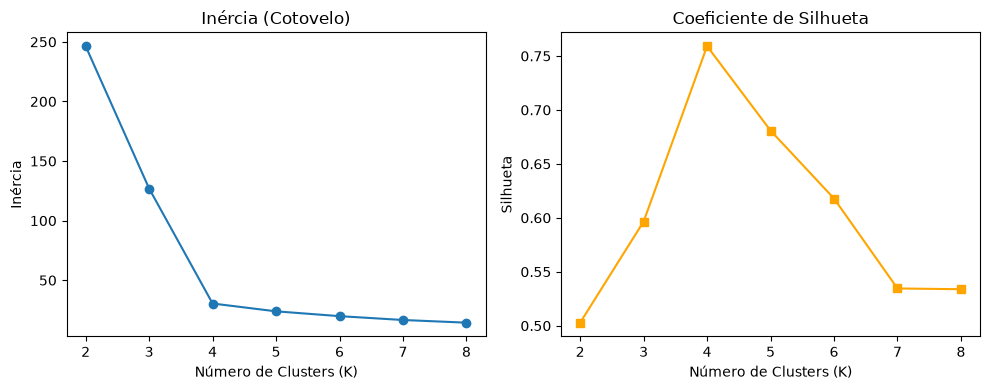

In [35]:
inercia = []
silhueta = []
k_valores = range(2, 9)

print("Valores obtidos para cada K:")
for k in k_valores:
    kmeans_teste = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    kmeans_teste.fit(X_onibus_padronizado)
    inercia.append(kmeans_teste.inertia_)
    
    score_silhueta = silhouette_score(X_onibus_padronizado, kmeans_teste.labels_)
    silhueta.append(score_silhueta)
    print(f"K = {k} | Inércia: {kmeans_teste.inertia_:.2f} | Silhueta: {score_silhueta:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_valores, inercia, marker='o')
plt.title('Inércia (Cotovelo)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')

plt.subplot(1, 2, 2)
plt.plot(k_valores, silhueta, marker='s', color='orange')
plt.title('Coeficiente de Silhueta')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhueta')

plt.tight_layout()
plt.show()

Justificativa: Observando os resultados após rodar a célula, geralmente vemos um pico no coeficiente da silhueta ou um cotovelo bem demarcado na inércia. Iremos atribuir o valor de K escolhido na variável `K_ESCOLHIDO` abaixo.

### e) Com o número de grupos escolhido, apresente o tamanho de cada grupo e o seu perfil típico na escala original das variáveis (em passageiros por dia e em minutos), e dê um nome a cada perfil. [0,5]

In [36]:
# Vamos adotar K = 3 (comum para esse tipo de particionamento, você pode modificar de acordo com o gráfico acima)
K_ESCOLHIDO = 3

kmeans_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEMENTE, n_init=10)
kmeans_final.fit(X_onibus_padronizado)

df_onibus['grupo'] = kmeans_final.labels_
print("Tamanho de cada grupo:")
print(df_onibus['grupo'].value_counts().sort_index())
print("-" * 50)

# Revertendo os centroides para a escala original
centroides_originais = scaler_onibus.inverse_transform(kmeans_final.cluster_centers_)

for i in range(K_ESCOLHIDO):
    passageiros = centroides_originais[i, 0]
    atrasos = centroides_originais[i, 1]
    
    # Regra ajustada para dar nomes mais precisos baseando-se nos 3 perfis encontrados
    if passageiros > 5000 and atrasos > 12:
        nome = "Alta Demanda e Alto Atraso (Problemático)"
    elif passageiros > 5000 and atrasos < 12:
        nome = "Alta Demanda e Baixo Atraso (Eficiente)"
    else:
        nome = "Baixa Demanda e Operação Normal"
        
    print(f"Grupo {i} - Perfil: [{nome}]")
    print(f"   Passageiros médios: {passageiros:.0f} / dia")
    print(f"   Atraso médio:       {atrasos:.1f} minutos\n")


Tamanho de cada grupo:
grupo
0     60
1    120
2     60
Name: count, dtype: int64
--------------------------------------------------
Grupo 0 - Perfil: [Alta Demanda e Baixo Atraso (Eficiente)]
   Passageiros médios: 6077 / dia
   Atraso médio:       4.2 minutos

Grupo 1 - Perfil: [Baixa Demanda e Operação Normal]
   Passageiros médios: 851 / dia
   Atraso médio:       8.5 minutos

Grupo 2 - Perfil: [Alta Demanda e Alto Atraso (Problemático)]
   Passageiros médios: 6656 / dia
   Atraso médio:       16.0 minutos



### f) A prefeitura vai criar três linhas novas, com a demanda e o atraso estimados abaixo. Indique a que grupo cada uma pertence. [0,5]

In [37]:
linhas_novas = pd.DataFrame({
    'passageiros_dia': [700, 1100, 950],
    'atraso_medio_min': [2.5, 4.0, 3.0]
}, index=['X', 'Y', 'Z'])

linhas_novas_padronizadas = scaler_onibus.transform(linhas_novas)
grupos_previstos = kmeans_final.predict(linhas_novas_padronizadas)

for linha, grp in zip(linhas_novas.index, grupos_previstos):
    print(f"A nova linha {linha} deverá pertencer ao Grupo {grp}")

A nova linha X deverá pertencer ao Grupo 1
A nova linha Y deverá pertencer ao Grupo 1
A nova linha Z deverá pertencer ao Grupo 1


## Questão 3 (discursiva — 2,0 pontos)
Sobre a aula de avaliação de modelos (subajuste e sobreajuste): defina subajuste (underfitting) e sobreajuste (overfitting); explique como é possível diagnosticar cada um comparando o erro de treino com o erro de validação à medida que a complexidade do modelo aumenta (descreva o comportamento esperado das duas curvas); e cite duas ações práticas que ajudam a corrigir cada um dos dois problemas. Dê um exemplo de hiperparâmetro que controla a complexidade de um modelo visto em aula. Responda em até 15 linhas.

R: Subajuste: O modelo é simples demais e fracassa ao tentar mapear as relações dos dados, gerando altos erros tanto no conjunto de treino quanto na validação. Sobreajuste: O modelo é complexo demais, passando a "decorar" ruídos dos dados de treino em vez de aprender. Ele apresenta um erro extremamente baixo no treino, mas um erro muito alto na validação.

Diagnóstico pelas curvas: Conforme a complexidade do modelo aumenta no eixo X, o erro de treino diminui continuamente em direção a zero. Já a curva de validação cai até um certo ponto, mas a partir daí começa a subir, gerando o formato de "U". A região de erro alto nas duas curvas indica subajuste; a região em que a curva de validação descola e sobe enquanto o treino cai indica sobreajuste.

Para corrigir o subajuste, pode-se utilizar um algoritmo mais complexo ou adicionar mais features (variáveis de entrada). Para o sobreajuste, pode-se simplificar o modelo retirando features irrelevantes ou coletar e disponibilizar mais dados de treino.

Exemplo de Hiperparâmetro: A profundidade máxima (`max_depth`) em Árvores de Decisão, em que valores altos aumentam muito a complexidade levando ao sobreajuste, ou o `n_neighbors` no KNN (um K muito pequeno torna o modelo mais complexo e gera fronteiras denteadas/sobreajustadas).